Loading: wishart_ma26_dynamic


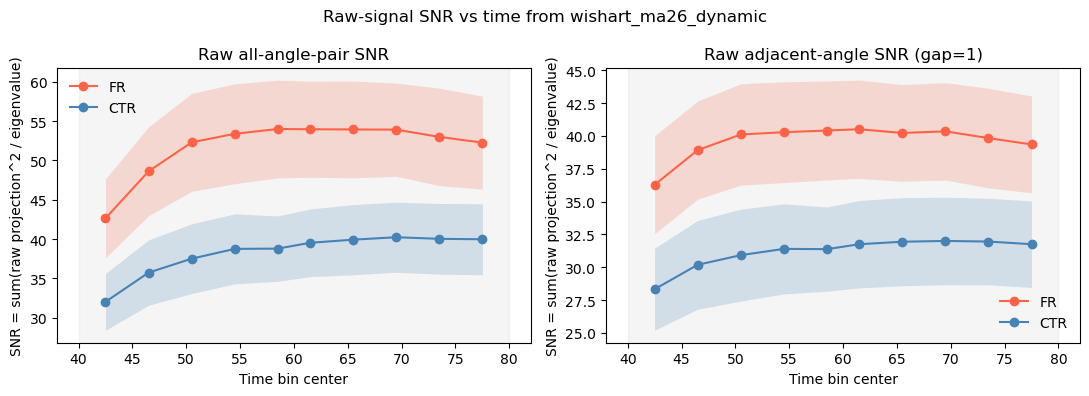

FR raw all-pair signal norm mean: 0.8129235387881151
FR raw adjacent signal norm mean: 0.7086631620409557
CTR raw all-pair signal norm mean: 0.6469362107094465
CTR raw adjacent signal norm mean: 0.5751661163008914


In [7]:
from pathlib import Path
import pickle
import re
import warnings
import numpy as np
import matplotlib.pyplot as plt

import z_castedo_snr_script_dynamic as base

# Find latest dynamic result directory
# candidate_dirs = [p for p in Path(".").glob("wishart*dynamic*") if p.is_dir()]
# if not candidate_dirs:
#     raise FileNotFoundError("No dynamic result directory matching 'wishart*dynamic*' found.")

# RESULTS_DIR = max(candidate_dirs, key=lambda p: p.stat().st_mtime)

RESULTS_DIR = Path("wishart_ma26_dynamic")
ANGLE_GAP_IDX = 0
NORMALIZE_OVERLAP = False
SUBSAMPLE_SEED = 13

print("Loading:", RESULTS_DIR)

deconv, angle, sf = base.load_sated_inputs()

files = sorted(RESULTS_DIR.glob("*_t*_overlaps_eigs.pkl"))
if not files:
    raise FileNotFoundError(f"No dynamic pickle files found in {RESULTS_DIR}")

fname_re = re.compile(r"^(FR|CTR)_t(\d+)_(\d+)_(\d+)_(\d+)_overlaps_eigs\.pkl$")
_resorted_cache = {}


def resorted_for_animal(animal):
    animal = int(animal)
    if animal not in _resorted_cache:
        _resorted_cache[animal] = base.resort_preprocessing(deconv, angle, sf, animal)
    return _resorted_cache[animal]


def raw_condition_means_for_saved_run(d):
    animal = int(d["animal"])
    start = int(d["start"])
    stop = int(d["stop"])

    raw = resorted_for_animal(animal)[:, :, :, :, start:stop]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        resp = np.nanmean(raw, axis=-1).transpose(3, 1, 2, 0)  # trials x angles x sfs x neurons
    resp = resp[~np.isnan(resp).any(axis=(1, 2, 3))]
    if resp.size == 0:
        raise ValueError(f"Animal {animal}, time {start}:{stop}: no complete raw trials")

    raw_mean = np.nanmean(resp, axis=0)  # angles x sfs x neurons

    neuron_indices = d.get("neuron_indices")
    if neuron_indices is not None:
        raw_mean = raw_mean[..., np.asarray(neuron_indices, dtype=int)]

    return raw_mean


def eigs_with_repeat_axis(d):
    eigs = np.asarray(d["eigs_per_condition"], dtype=float)
    if eigs.ndim == 3:
        eigs = eigs[..., None]
    if eigs.ndim != 4:
        raise ValueError(f"Unexpected eigs_per_condition shape: {eigs.shape}")
    return eigs


def covariance_grid_for_saved_run(d, c1, c2, n_neurons):
    covs = np.asarray(d["sigma_orig_mode"], dtype=float)
    if covs.shape == (c1 * c2, n_neurons, n_neurons):
        return covs.reshape(c1, c2, n_neurons, n_neurons)
    if covs.shape == (c1, c2, n_neurons, n_neurons):
        return covs
    raise ValueError(
        "Unexpected sigma_orig_mode shape "
        f"{covs.shape}; expected ({c1 * c2}, {n_neurons}, {n_neurons}) "
        f"or ({c1}, {c2}, {n_neurons}, {n_neurons})"
    )


def repeat_neuron_indices(d, n_neurons, kmax, repeats):
    neuron_indices = d.get("neuron_indices")
    if neuron_indices is not None:
        idx = np.asarray(neuron_indices, dtype=int)
        return [idx for _ in range(repeats)]

    # This matches compute_noise_metrics_all() for runs where total_k is None.
    if d.get("total_k", "all") is None:
        return [
            np.random.default_rng(SUBSAMPLE_SEED + r).choice(n_neurons, kmax, replace=False)
            for r in range(repeats)
        ]

    full_idx = np.arange(n_neurons)
    return [full_idx for _ in range(repeats)]


def projection_squared(sv, pc, norm):
    dot2 = np.dot(sv, pc) ** 2
    if NORMALIZE_OVERLAP:
        return dot2 / (norm ** 2) if norm > 0 else np.nan
    return dot2


def raw_overlaps_and_eigs_for_saved_run(d):
    raw_mean = raw_condition_means_for_saved_run(d)
    c1, c2, n_neurons = raw_mean.shape

    eigs_saved = eigs_with_repeat_axis(d)
    kmax = eigs_saved.shape[2]
    repeats = eigs_saved.shape[3]
    covs = covariance_grid_for_saved_run(d, c1, c2, n_neurons)

    raw_overlap = np.full((c1, c1 - 1, c2, kmax, repeats), np.nan)
    raw_adjacent_overlap = np.full((c1, c2, kmax, repeats), np.nan)
    raw_eigs = np.full((c1, c2, kmax, repeats), np.nan)
    raw_norm = np.full((c1, c1 - 1, c2, repeats), np.nan)
    raw_adjacent_norm = np.full((c1, c2, repeats), np.nan)

    for r, idx in enumerate(repeat_neuron_indices(d, n_neurons, kmax, repeats)):
        resp_r = raw_mean[..., idx]
        covs_r = covs
        if len(idx) != n_neurons:
            covs_r = np.take(covs_r, idx, axis=2)
            covs_r = np.take(covs_r, idx, axis=3)

        for isf in range(c2):
            for ia in range(c1):
                try:
                    evals, evecs = np.linalg.eigh(covs_r[ia, isf])
                except np.linalg.LinAlgError:
                    continue

                order = np.argsort(evals)[::-1]
                evals = evals[order]
                evecs = evecs[:, order]
                modes = min(kmax, evecs.shape[1])
                raw_eigs[ia, isf, :modes, r] = evals[:modes]

                others = (ia + np.arange(1, c1)) % c1
                for j, ja in enumerate(others):
                    sv = resp_r[ia, isf, :] - resp_r[ja, isf, :]
                    norm = np.linalg.norm(sv)
                    raw_norm[ia, j, isf, r] = norm
                    for k in range(modes):
                        raw_overlap[ia, j, isf, k, r] = projection_squared(sv, evecs[:, k], norm)

                ja = (ia + ANGLE_GAP_IDX + 1) % c1
                sv = resp_r[ia, isf, :] - resp_r[ja, isf, :]
                norm = np.linalg.norm(sv)
                raw_adjacent_norm[ia, isf, r] = norm
                for k in range(modes):
                    raw_adjacent_overlap[ia, isf, k, r] = projection_squared(sv, evecs[:, k], norm)

    return raw_overlap, raw_adjacent_overlap, raw_eigs, raw_norm, raw_adjacent_norm


rows = []
raw_mode_rows = []

for path in files:
    m = fname_re.match(path.name)
    if m is None:
        continue

    group = m.group(1)
    t_idx = int(m.group(2))

    with open(path, "rb") as f:
        d = pickle.load(f)

    start = int(d["start"])
    stop = int(d["stop"])
    center = 0.5 * (start + stop)
    animal = int(d["animal"])

    overlaps, adjacent_overlaps, eigs, norms, adjacent_norms = raw_overlaps_and_eigs_for_saved_run(d)
    eigs_pos = np.where(eigs > 0, eigs, np.nan)

    # Normal: raw angle-pair vectors, shape (angles, angle_pairs, sfs, modes, repeats).
    normal_snr_modes = overlaps / eigs_pos[:, None, :, :, :]
    normal_snr = np.nansum(normal_snr_modes, axis=3)

    # Raw analogue of the previous small-angle panel: adjacent observed-angle vectors.
    adjacent_snr_modes = adjacent_overlaps / eigs_pos
    adjacent_snr = np.nansum(adjacent_snr_modes, axis=2)

    rows.append({
        "group": group,
        "animal": animal,
        "t_idx": t_idx,
        "start": start,
        "stop": stop,
        "center": center,
        "normal": np.nanmean(normal_snr),
        "adjacent": np.nanmean(adjacent_snr),
        "normal_norm": np.nanmean(norms),
        "adjacent_norm": np.nanmean(adjacent_norms),
    })

    raw_mode_rows.append({
        "group": group,
        "animal": animal,
        "t_idx": t_idx,
        "start": start,
        "stop": stop,
        "center": center,
        "normal_overlap_by_mode": np.nanmean(overlaps, axis=(0, 1, 2, 4)),
        "adjacent_overlap_by_mode": np.nanmean(adjacent_overlaps, axis=(0, 1, 3)),
        "eig_by_mode": np.nanmean(eigs, axis=(0, 1, 3)),
    })


def group_time_stats(rows, group, metric):
    t_idxs = sorted({r["t_idx"] for r in rows if r["group"] == group})
    centers, means, sems = [], [], []

    for t in t_idxs:
        vals = np.array([r[metric] for r in rows if r["group"] == group and r["t_idx"] == t], dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue

        center = np.mean([r["center"] for r in rows if r["group"] == group and r["t_idx"] == t])
        centers.append(center)
        means.append(np.nanmean(vals))
        sems.append(np.nanstd(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0)

    return np.array(centers), np.array(means), np.array(sems)


colors = {"FR": "tomato", "CTR": "steelblue"}
ylabel = "SNR = sum(raw projection^2 / eigenvalue)"
if NORMALIZE_OVERLAP:
    ylabel = "SNR = sum(raw projection^2 / raw signal norm^2 / eigenvalue)"

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

for ax, metric, title in zip(
    axes,
    ["normal", "adjacent"],
    ["Raw all-angle-pair SNR", f"Raw adjacent-angle SNR (gap={ANGLE_GAP_IDX + 1})"],
):
    for group in ["FR", "CTR"]:
        x, y, sem = group_time_stats(rows, group, metric)
        if len(x) == 0:
            continue

        ax.plot(x, y, marker="o", color=colors[group], label=group)
        ax.fill_between(x, y - sem, y + sem, color=colors[group], alpha=0.2, linewidth=0)

    ax.axvspan(40, 80, color="gray", alpha=0.08)
    ax.set_title(title)
    ax.set_xlabel("Time bin center")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)

plt.suptitle(f"Raw-signal SNR vs time from {RESULTS_DIR.name}")
plt.tight_layout()
plt.show()

for group in ["FR", "CTR"]:
    group_rows = [r for r in rows if r["group"] == group]
    if not group_rows:
        continue
    print(f"{group} raw all-pair signal norm mean:", np.nanmean([r["normal_norm"] for r in group_rows]))
    print(f"{group} raw adjacent signal norm mean:", np.nanmean([r["adjacent_norm"] for r in group_rows]))


In [ ]:
from pathlib import Path
import pickle
import re
import warnings
import numpy as np
import matplotlib.pyplot as plt

import z_castedo_snr_script_dynamic as base

DATA_FOLDER = "wishart_ma26_dynamic"

angle_gap_idx = 0
mode_start = 0
normalize_overlap = False  # set True for dot^2 / ||raw signal||^2
time_idx_to_plot = None    # None averages all dynamic windows; or set 0, 1, ..., 9

deconv, angle, sf = base.load_sated_inputs()
_resorted_cache = {}


def nansem(x, axis=0):
    n = np.sum(np.isfinite(x), axis=axis)
    return np.nanstd(x, axis=axis, ddof=1) / np.sqrt(n)


def resorted_for_animal(animal):
    animal = int(animal)
    if animal not in _resorted_cache:
        _resorted_cache[animal] = base.resort_preprocessing(deconv, angle, sf, animal)
    return _resorted_cache[animal]


def raw_condition_means_for_saved_run(d):
    animal = int(d["animal"])
    start = int(d["start"])
    stop = int(d["stop"])

    raw = resorted_for_animal(animal)[:, :, :, :, start:stop]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        resp = np.nanmean(raw, axis=-1).transpose(3, 1, 2, 0)  # trials x angles x sfs x neurons
    resp = resp[~np.isnan(resp).any(axis=(1, 2, 3))]

    if "neuron_indices" in d:
        neuron_indices = np.asarray(d["neuron_indices"], dtype=int)
        resp = resp[..., neuron_indices]

    raw_mean = np.nanmean(resp, axis=0)  # angles x sfs x selected_neurons

    return raw_mean


def raw_overlap_and_eigs_for_file(path):
    with open(path, "rb") as fh:
        d = pickle.load(fh)

    raw_mean = raw_condition_means_for_saved_run(d)
    covs = np.asarray(d["sigma_orig_mode"])       # (angles*sfs, neurons, neurons)
    eigs_saved = np.asarray(d["eigs_per_condition"])

    c1, c2, n_neurons = raw_mean.shape
    if covs.shape == (c1 * c2, n_neurons, n_neurons):
        covs = covs.reshape(c1, c2, n_neurons, n_neurons)
    elif covs.shape != (c1, c2, n_neurons, n_neurons):
        raise ValueError(f"Unexpected sigma_orig_mode shape for {path.name}: {covs.shape}")

    kmax = eigs_saved.shape[2]
    raw_overlap = np.full((c1, c2, kmax), np.nan)
    raw_norm = np.full((c1, c2), np.nan)
    raw_eigs = np.full((c1, c2, kmax), np.nan)

    for ia in range(c1):
        ja = (ia + angle_gap_idx + 1) % c1

        for isf in range(c2):
            sv = raw_mean[ia, isf, :] - raw_mean[ja, isf, :]
            raw_norm[ia, isf] = np.linalg.norm(sv)

            evals, evecs = np.linalg.eigh(covs[ia, isf])
            order = np.argsort(evals)[::-1]
            evals = evals[order]
            evecs = evecs[:, order]

            raw_eigs[ia, isf, :] = evals[:kmax]

            for k in range(kmax):
                dot2 = np.dot(sv, evecs[:, k]) ** 2
                if normalize_overlap:
                    dot2 = dot2 / (raw_norm[ia, isf] ** 2)
                raw_overlap[ia, isf, k] = dot2

    return int(d["animal"]), int(d["start"]), int(d["stop"]), raw_overlap, raw_eigs, raw_norm


def load_raw_overlap_group(prefix, folder=DATA_FOLDER):
    rows = []
    fname_re = re.compile(rf"^{prefix}_t(\d+)_(\d+)_(\d+)_(\d+)_overlaps_eigs\.pkl$")

    for path in Path(folder).glob(f"{prefix}_t*_overlaps_eigs.pkl"):
        m = fname_re.match(path.name)
        if m is None:
            continue

        t_idx = int(m.group(1))
        if time_idx_to_plot is not None and t_idx != int(time_idx_to_plot):
            continue

        animal, start, stop, overlap, eigs, norm = raw_overlap_and_eigs_for_file(path)
        rows.append((animal, t_idx, start, stop, overlap, eigs, norm))

    rows.sort(key=lambda x: (x[0], x[1]))

    animals = np.array(sorted({animal for animal, _, _, _, _, _, _ in rows}))
    time_idxs = np.array(sorted({t_idx for _, t_idx, _, _, _, _, _ in rows}))
    centers = np.array([
        np.mean([0.5 * (start + stop) for _, t_idx, start, stop, _, _, _ in rows if t_idx == wanted_t])
        for wanted_t in time_idxs
    ])

    lookup = {(animal, t_idx): (overlap, eigs, norm)
              for animal, t_idx, _, _, overlap, eigs, norm in rows}

    overlaps = np.stack([
        np.stack([lookup[(animal, t_idx)][0] for t_idx in time_idxs], axis=0)
        for animal in animals
    ], axis=0)
    # animals x time_windows x angles x sfs x modes

    eigs = np.stack([
        np.stack([lookup[(animal, t_idx)][1] for t_idx in time_idxs], axis=0)
        for animal in animals
    ], axis=0)
    # animals x time_windows x angles x sfs x modes

    norms = np.stack([
        np.stack([lookup[(animal, t_idx)][2] for t_idx in time_idxs], axis=0)
        for animal in animals
    ], axis=0)
    # animals x time_windows x angles x sfs

    return animals, time_idxs, centers, overlaps, eigs, norms


FR_animals, FR_time_idxs, FR_centers, FR_raw_overlap, FR_raw_eigs, FR_raw_norms = load_raw_overlap_group("FR")
CTR_animals, CTR_time_idxs, CTR_centers, CTR_raw_overlap, CTR_raw_eigs, CTR_raw_norms = load_raw_overlap_group("CTR")

fr_overlap_by_animal = np.nanmean(FR_raw_overlap, axis=(1, 2, 3))  # animals x modes
fr_eigs_by_animal = np.nanmean(FR_raw_eigs, axis=(1, 2, 3))        # animals x modes

ctr_overlap_by_animal = np.nanmean(CTR_raw_overlap, axis=(1, 2, 3))
ctr_eigs_by_animal = np.nanmean(CTR_raw_eigs, axis=(1, 2, 3))

fr_overlap_mean = np.nanmean(fr_overlap_by_animal, axis=0)
fr_overlap_err = nansem(fr_overlap_by_animal, axis=0)
fr_eigs_mean = np.nanmean(fr_eigs_by_animal, axis=0)

ctr_overlap_mean = np.nanmean(ctr_overlap_by_animal, axis=0)
ctr_overlap_err = nansem(ctr_overlap_by_animal, axis=0)
ctr_eigs_mean = np.nanmean(ctr_eigs_by_animal, axis=0)

sl = slice(mode_start, None)

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    fr_eigs_mean[sl],
    fr_overlap_mean[sl],
    yerr=fr_overlap_err[sl],
    marker="o",
    capsize=3,
    label=f"FR raw signal, n={len(FR_animals)}",
)

ax.errorbar(
    ctr_eigs_mean[sl],
    ctr_overlap_mean[sl],
    yerr=ctr_overlap_err[sl],
    marker="o",
    capsize=3,
    label=f"CTR raw signal, n={len(CTR_animals)}",
)

ax.set_xlabel("Inferred covariance eigenvalue")
ax.set_ylabel("Raw-data signal projection" + (" / raw signal norm^2" if normalize_overlap else ""))
time_label = "all dynamic windows" if time_idx_to_plot is None else f"t_idx={time_idx_to_plot}"
ax.set_title(f"{DATA_FOLDER}, raw signal vectors, {time_label}")
ax.legend()
plt.show()

print("FR dynamic time idxs:", FR_time_idxs)
print("CTR dynamic time idxs:", CTR_time_idxs)
print("FR raw signal norm mean:", np.nanmean(FR_raw_norms))
print("CTR raw signal norm mean:", np.nanmean(CTR_raw_norms))
